# Lab 7.05 - Time series analysis

In [2]:
# Package imports
import numpy as np                                  # "Scientific computing"
import pandas as pd                                 # Dataframe

import scipy.stats as stats                         # Statistical tests
from sklearn.linear_model import LinearRegression   # Linear regression model

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz

### Exercise 5 - Alcoholic beverages sales

The file US Retail.csv contains monthly retail sales of beer, wine, and liquor at U.S. liquor stores.

- Is seasonality present in these data?
- Create a time series chart of the data. Based on what you see, which of the exponential smoothing models do you think should be used for forecasting? Why?
- Split the dataset in a train (1992-01-01 up to and including 2008-12-01) and test set (2009-01-01 up to and including 2009-12-01)  
- Create and train the model.
- Predict the values for 2009.
- Create a plot with the train data, the fitted values, the test data and the predicted values.
- Calculate MAE

In [3]:
data = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/US%20Retail.csv', delimiter = ";", parse_dates=['Month']).set_index(['Month'])
data.head()

,Total Sales
Month,
1992-01-01,1519
1992-02-01,1551
1992-03-01,1606
1992-04-01,1686
1992-05-01,1834


<Axes: xlabel='Month'>

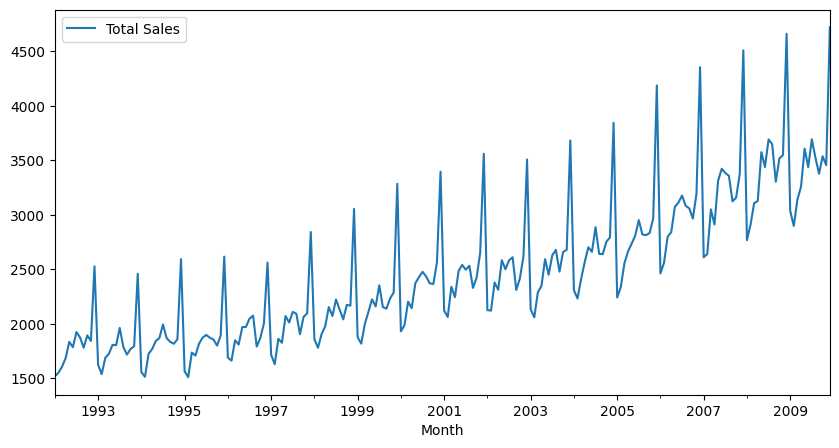

In [4]:
data.plot(y='Total Sales', figsize=[10,5])

In [14]:
# Les oplossing | Train the model
train = data['Total Sales'][:'2008-12-01']
test = data['Total Sales']['2009-01-01':]


from statsmodels.tsa.holtwinters import ExponentialSmoothing

data_tes = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='mul',
    seasonal_periods=12,
    freq='MS'
).fit()
des_fcast = data_tes.forecast(12)
des_fcast.head()

,0
2009-01-01,2969.920841
2009-02-01,2966.259788
2009-03-01,3280.295971
2009-04-01,3300.551838
2009-05-01,3607.343262


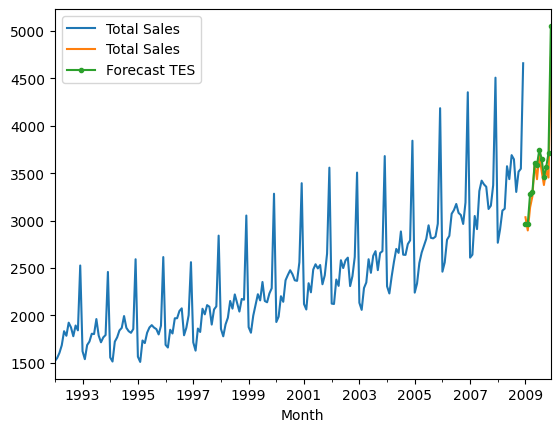

In [16]:
#Plot predicted values
train.plot(legend=True) #blauw
test.plot(legend=True) #oranje

des_fcast.plot(
    marker='.',
    legend=True,
    label='Forecast TES' #groen
);

In [15]:
# MAE berekenen
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = test.values
y_predicted = des_fcast.values

mean_absolute_error(y_true, y_predicted)

113.71209743310392

## Source
Business Analytics Data Analysis & Decision Making